### Your name:

<pre> Shamir Alavi</pre>

### Collaborators:

<pre> None </pre>


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Open the housing data


In [2]:
import os
import tarfile

HOUSING_PATH = os.path.join('..', 'data')

def fetch_housing_data(housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

# fetch_housing_data()

import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing_original = load_housing_data()
housing_original.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Build full pipeline for the data analysis following the example of the notebook.
 Hint: the main part requested to change is the algorithm used (KNN regression)


#### Considerations for building pipeline:

- Make your notebook as compact as possible. 
- Split data into training and testing sets below.
- Convert all categorical data to one-hot vectors below
- Normalize all non-categorical data 
-  Perform KNN regression using a variety of values for n_neighbors (K) between 1 and 10 and both "uniform" and "distance" weights via a grid search where  *housing_labels* is the output and all other features are the input (similar to as seen in lecture two.)

## Clean bad data
Looks like median house values, some median house values were capped to their nearest round number instead of keeping the original values. These are data artifacts we want to remove to keep the dataset clean. 

In [3]:
suspicious_values = [
    450000, 400000, 375000, 350000, 325000, 300000, 275000,
    250000, 225000, 200000, 187500, 175000, 162500, 150000,
    137500, 125000, 112500, 100000, 87500, 75000, 67500
]

housing = housing_original[
    ~housing_original["median_house_value"].isin(suspicious_values)
]

# Make sure there are no missing indices after removing rows
housing = housing.reset_index(drop=True)

housing.shape

(19330, 10)

### Stratify by household median income

In [4]:
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0.,1.5,3.0,4.5,6.,np.inf], labels=[1,2,3,4,5])
housing.shape

(19330, 11)

In [ ]:
housing["income_cat"].hist()
plt.show()

### Split dataset into training and test sets

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

# Create dataset generator
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

### Perform stratified imputation of missing values in training set

In [ ]:
housing.info()

In [6]:
train_medians = strat_train_set.groupby("income_cat")["total_bedrooms"].median()

# Apply medians learned from training set on both training and test sets
strat_train_set["total_bedrooms"] = strat_train_set.apply(
    lambda row: train_medians[row["income_cat"]] if pd.isna(row["total_bedrooms"]) else row["total_bedrooms"],
    axis=1
)

strat_test_set["total_bedrooms"] = strat_test_set.apply(
    lambda row: train_medians[row["income_cat"]] if pd.isna(row["total_bedrooms"]) else row["total_bedrooms"],
    axis=1
)

In [7]:
housing['total_bedrooms'].median()

np.float64(440.0)

In [8]:
train_medians

income_cat
1    374.0
2    454.0
3    463.0
4    432.5
5    403.0
Name: total_bedrooms, dtype: float64

### Create new features

In [9]:
# bedrooms_ratio, rooms_per_bedroom (how many rooms are there for each bedroom)
strat_train_set["bedrooms_ratio"] = strat_train_set["total_bedrooms"] / strat_train_set["total_rooms"]
strat_train_set["rooms_per_bedroom"] = strat_train_set["total_rooms"] / strat_train_set["total_bedrooms"]

strat_test_set["bedrooms_ratio"] = strat_test_set["total_bedrooms"] / strat_test_set["total_rooms"]
strat_test_set["rooms_per_bedroom"] = strat_test_set["total_rooms"] / strat_test_set["total_bedrooms"]

In [10]:
strat_train_set.shape
strat_test_set.shape

(3866, 13)

### Drop income category (income_cat) used for stratification

In [ ]:
strat_test_set.columns

In [11]:
strat_train_set = strat_train_set.drop('income_cat', axis=1)
strat_test_set = strat_test_set.drop('income_cat', axis=1)

In [12]:
strat_train_set.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'bedrooms_ratio',
       'rooms_per_bedroom'],
      dtype='str')

### Drop label from training set

In [13]:
# Set labels aside from training set
housing = strat_train_set.drop("median_house_value", axis=1).copy() # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy()

In [14]:
housing.info()

<class 'pandas.DataFrame'>
Index: 15464 entries, 1883 to 16831
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           15464 non-null  float64
 1   latitude            15464 non-null  float64
 2   housing_median_age  15464 non-null  float64
 3   total_rooms         15464 non-null  float64
 4   total_bedrooms      15464 non-null  float64
 5   population          15464 non-null  float64
 6   households          15464 non-null  float64
 7   median_income       15464 non-null  float64
 8   ocean_proximity     15464 non-null  str    
 9   bedrooms_ratio      15464 non-null  float64
 10  rooms_per_bedroom   15464 non-null  float64
dtypes: float64(10), str(1)
memory usage: 1.4 MB


In [ ]:
housing_labels.info()

### Encode categorical features (one-hot encoding)

In [ ]:
housing_cat = housing[["ocean_proximity"]]
housing_cat['ocean_proximity'].value_counts()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

In [ ]:
cat_encoder.categories_

### Feature scaling

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))

plt.show()

### Create new features using RBF for multimodal housing_median_age

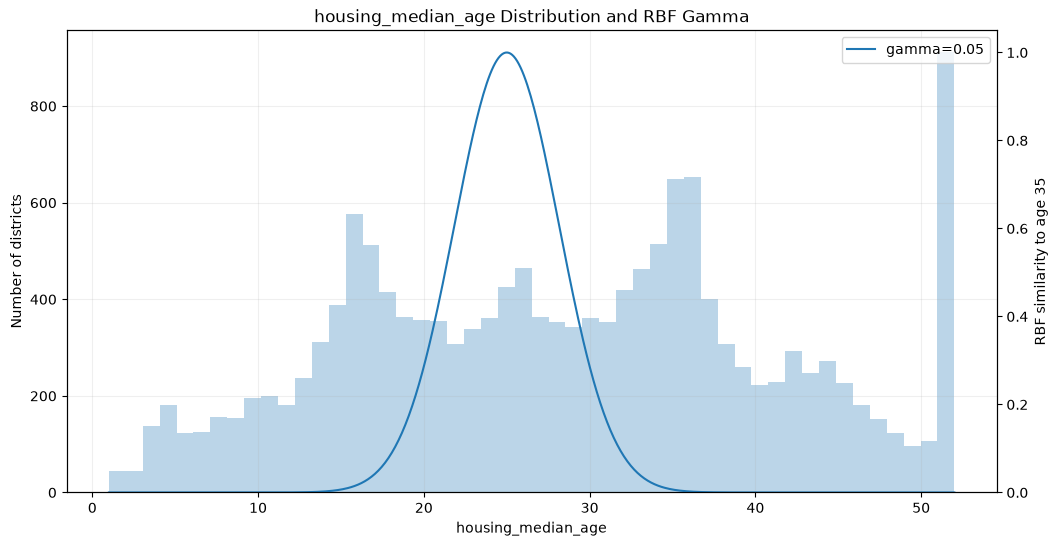

In [ ]:
# Visualize the effect of gamma on similarity measures 
ages = housing["housing_median_age"]
center = 25
# gammas = [0.001, 0.01, 0.05, 0.1, 0.5]    # higher is steeper
gammas = [0.05]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Histogram of actual housing_median_age values
ax1.hist(
    ages,
    bins=50,
    alpha=0.3
)

ax1.set_xlabel("housing_median_age")
ax1.set_ylabel("Number of districts")

# RBF curves
ax2 = ax1.twinx()

age_range = np.linspace(ages.min(), ages.max(), 500)

for gamma in gammas:
    similarity = np.exp(-gamma * (age_range - center) ** 2)
    ax2.plot(
        age_range,
        similarity,
        label=f"gamma={gamma}"
    )

ax2.set_ylabel("RBF similarity to age 35")
ax2.set_ylim(0, 1.05)

plt.title("housing_median_age Distribution and RBF Gamma")
ax2.legend()
ax1.grid(True, alpha=0.2)

plt.show()

In [ ]:
from sklearn.metrics.pairwise import rbf_kernel

housing["age_simil_15"] = rbf_kernel(housing[["housing_median_age"]], [[15]], gamma=0.025)
housing["age_simil_25"] = rbf_kernel(housing[["housing_median_age"]], [[25]], gamma=0.025)
housing["age_simil_35"] = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.025)
housing["age_simil_50"] = rbf_kernel(housing[["housing_median_age"]], [[50]], gamma=0.025)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
housing_numeric = housing.drop('ocean_proximity', axis=1)
housing_scaled = scaler.fit_transform(housing_numeric)

In [ ]:
housing_scaled = pd.DataFrame(housing_scaled)
housing_scaled.hist(bins=50, figsize=(20,15))

plt.show()

In [ ]:
housing.columns

### Create pipeline

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor


log_cols = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "bedrooms_ratio",
    "rooms_per_bedroom"
]

standard_cols = [
    "longitude",
    "latitude",
    "housing_median_age"
]

cat_cols = [
    "ocean_proximity"
]


log_pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler())
])


preprocessing_no_rbf = ColumnTransformer([
    ("log", log_pipeline, log_cols),
    ("standard", StandardScaler(), standard_cols),
    ("cat", OneHotEncoder(), cat_cols)
])


knn_no_rbf = Pipeline([
    ("preprocessing", preprocessing_no_rbf),
    ("regressor", KNeighborsRegressor(n_neighbors=5, weights='uniform'))
])


knn_no_rbf.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['longitude','latitude','housing_median_age',...,'ocean_proximity', 'bedrooms_ratio','rooms_per_bedroom']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('standard', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

In [24]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

predictions_no_rbf = knn_no_rbf.predict(some_data)

print("Predictions:", predictions_no_rbf)

Predictions: [ 76620.   80680.   53060.  470420.8 340080. ]


In [ ]:

print("Labels:", list(some_labels))

Labels: [73900.0, 83100.0, 44400.0, 500001.0, 301000.0]


### Create Pipeline 2: With RBF features

In [ ]:
from sklearn.metrics.pairwise import rbf_kernel

gamma = 0.025

def rbf_features(X):
    return np.hstack([
        rbf_kernel(X, [[15]], gamma=gamma),
        rbf_kernel(X, [[25]], gamma=gamma),
        rbf_kernel(X, [[35]], gamma=gamma),
        rbf_kernel(X, [[50]], gamma=gamma)
    ])


rbf_pipeline = FunctionTransformer(rbf_features)


preprocessing_rbf = ColumnTransformer([
    ("log", log_pipeline, log_cols),
    ("standard", StandardScaler(), standard_cols),
    ("rbf", rbf_pipeline, ["housing_median_age"]),
    ("cat", OneHotEncoder(), cat_cols)
])


knn_rbf = Pipeline([
    ("preprocessing", preprocessing_rbf),
    ("regressor", KNeighborsRegressor(n_neighbors=5))
])


knn_rbf.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['longitude','latitude','housing_median_age',...,'ocean_proximity', 'bedrooms_ratio','rooms_per_bedroom']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('standard', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

In [67]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

predictions_rbf = knn_rbf.predict(some_data)

print("Predictions:", predictions_rbf)

Predictions: [ 76620.   82060.   53580.  470420.8 327800. ]


In [46]:
print("Labels:", list(some_labels))

Labels: [73900.0, 83100.0, 44400.0, 500001.0, 301000.0]


### Calculate RMSE

In [68]:
from sklearn.metrics import root_mean_squared_error

rmse_no_rbf = root_mean_squared_error(
    some_labels,
    predictions_no_rbf
)

rmse_rbf = root_mean_squared_error(
    some_labels,
    predictions_rbf
)

print("KNN without RBF:", rmse_no_rbf)
print("KNN with RBF:", rmse_rbf)

KNN without RBF: 22318.086979129734
KNN with RBF: 18362.900816809964


##### => Use KNN with RBF features with gamma = 0.025

## Training with Cross Validation

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV


# Features
log_cols = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "bedrooms_ratio",
    "rooms_per_bedroom"
]

standard_cols = [
    "longitude",
    "latitude",
    "housing_median_age"
]

cat_cols = [
    "ocean_proximity"
]


# Log transformation + scaling
log_pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p)),
    ("scale", StandardScaler())
])


# RBF features
def rbf_features(X):
    return np.hstack([
        rbf_kernel(X, [[15]], gamma=0.025),
        rbf_kernel(X, [[25]], gamma=0.025),
        rbf_kernel(X, [[35]], gamma=0.025),
        rbf_kernel(X, [[50]], gamma=0.025)
    ])


rbf_pipeline = FunctionTransformer(rbf_features)


# Full preprocessing pipeline
preprocessing = ColumnTransformer([
    ("log", log_pipeline, log_cols),
    ("standard", StandardScaler(), standard_cols),
    ("rbf", rbf_pipeline, ["housing_median_age"]),
    ("cat", OneHotEncoder(), cat_cols)
])


# Full model pipeline
knn = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", KNeighborsRegressor())
])


# Grid search
param_grid = {
    "regressor__n_neighbors": range(1, 11),
    "regressor__weights": ["uniform", "distance"]
}


grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

%%timeit
# Run grid search on the training set
grid_search.fit(strat_train_set.drop("median_house_value", axis=1),
                strat_train_set["median_house_value"])


print("Best parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

In [ ]:
from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

In [ ]:
t_start()
tree_reg = DecisionTreeRegressor(random_state=42)
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
t_end()

tree_rmse_scores = np.sqrt(-scores)

display_scores(tree_rmse_scores)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Write your code here:

In [ ]:
# Write your code here

### Conclusions
For what values of n_neighbors and weight does KNeighborsRegressor perform the best? Does it perform as well on the housing data as the linear regressor from the lectures? Why do you think this is?

<pre> WRITE RESPONSE HERE </pre>

### Read appending B

- Reflect on your last data project, read appendix B. Then, write down a few of the checklist items that your last data project could have used. If you have not yet done a data project, then write down a few of the items that you found most interesting.


### Submit your notebook

Submit your solution to Quercus
Make sure you rename your notebook to    
W2_UTORid.ipynb    
Example W2_adfasd01.ipynb
